In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/loan_data.csv')
df.head()


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22,female,Master,71948,0,RENT,35000,PERSONAL,16.02,0.49,3,561,No,1
1,21,female,High School,12282,0,OWN,1000,EDUCATION,11.14,0.08,2,504,Yes,0
2,25,female,High School,12438,3,MORTGAGE,5500,MEDICAL,12.87,0.44,3,635,No,1
3,23,female,Bachelor,79753,0,RENT,35000,MEDICAL,15.23,0.44,2,675,No,1
4,24,male,Master,66135,1,RENT,35000,MEDICAL,14.27,0.53,4,586,No,1


In [4]:
df.shape


df.info()

df.describe()

df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  int64  
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  int64  
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  int64  
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  int64  
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


Exploratory Data Analysis

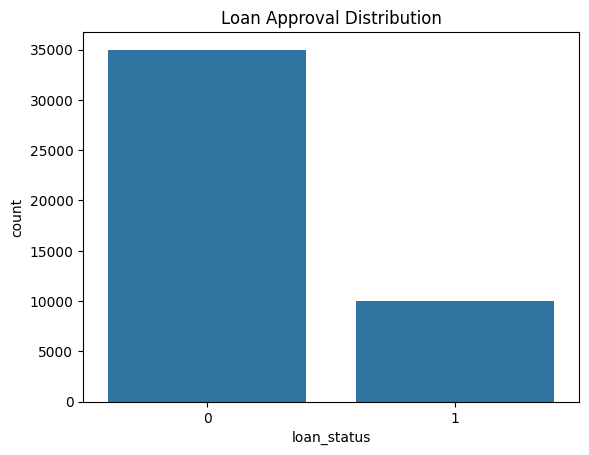

In [5]:
#Target Distribution
sns.countplot(
    x="loan_status",
    data=df
)

plt.title("Loan Approval Distribution")
plt.show()

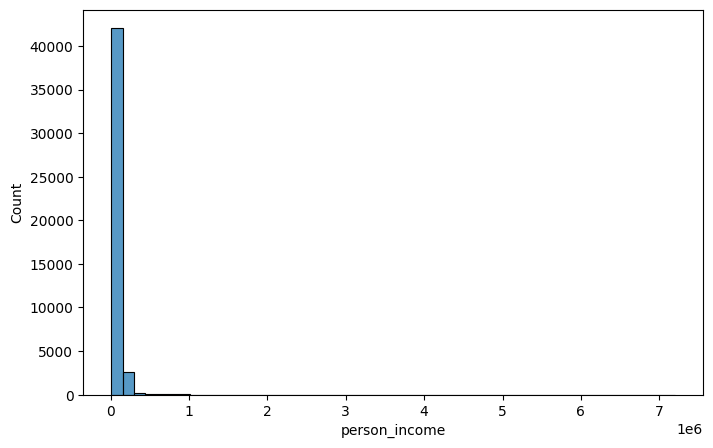

In [6]:
#Income Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["person_income"],
    bins=50
)

plt.show()

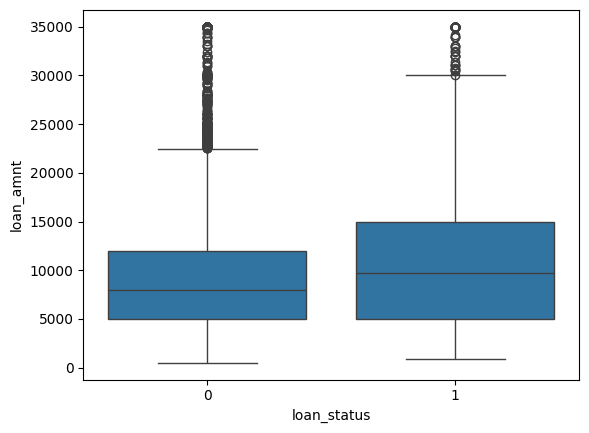

In [7]:
#Loan Amount Analysis
sns.boxplot(
    x="loan_status",
    y="loan_amnt",
    data=df
)

plt.show()

Handle Missing Values

In [8]:
df.isnull().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


In [9]:
df.fillna(
    df.median(numeric_only=True),
    inplace=True
)
for col in df.select_dtypes('object'):
    df[col].fillna(
        df[col].mode()[0],
        inplace=True
    )

/tmp/ipykernel_521/2924147002.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(


Encode Categorical Variables

In [10]:
from sklearn.preprocessing import LabelEncoder

encoders = {}

for col in df.select_dtypes("object"):
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le

In [11]:
for key, encoder in encoders.items():
    print(key, ":", encoder.classes_)

person_gender : ['female' 'male']
person_education : ['Associate' 'Bachelor' 'Doctorate' 'High School' 'Master']
person_home_ownership : ['MORTGAGE' 'OTHER' 'OWN' 'RENT']
loan_intent : ['DEBTCONSOLIDATION' 'EDUCATION' 'HOMEIMPROVEMENT' 'MEDICAL' 'PERSONAL'
 'VENTURE']
previous_loan_defaults_on_file : ['No' 'Yes']


In [12]:
import pickle

with open("encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

In [13]:
from google.colab import files

files.download("encoders.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Split Features and Target

In [14]:
X = df.drop(
    "loan_status",
    axis=1
)
y = df["loan_status"]


In [15]:
print(X.columns.tolist())
print("Number of features:", X.shape[1])

['person_age', 'person_gender', 'person_education', 'person_income', 'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score', 'previous_loan_defaults_on_file']
Number of features: 13


Feature Scaling

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Build ANN Model

In [18]:
model = Sequential()


model.add(
    Dense(
        128,
        activation="relu",
        input_shape=(X_train.shape[1],)
    )
)


model.add(
    Dropout(0.3)
)


model.add(
    Dense(
        64,
        activation="relu"
    )
)


model.add(
    Dense(
        32,
        activation="relu"
    )
)


model.add(
    Dense(
        1,
        activation="sigmoid"
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Compile Model

In [19]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

Train ANN

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8790 - loss: 0.2558 - val_accuracy: 0.8868 - val_loss: 0.2324
Epoch 2/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9003 - loss: 0.2192 - val_accuracy: 0.8929 - val_loss: 0.2233
Epoch 3/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9035 - loss: 0.2138 - val_accuracy: 0.8997 - val_loss: 0.2132
Epoch 4/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9059 - loss: 0.2080 - val_accuracy: 0.8994 - val_loss: 0.2145
Epoch 5/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9055 - loss: 0.2056 - val_accuracy: 0.9032 - val_loss: 0.2100
Epoch 6/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9073 - loss: 0.2042 - val_accuracy: 0.9018 - val_loss: 0.2098
Epoch 7/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9086 - loss: 0.2010 - val_accuracy: 0.9049 - val_loss: 0.2057
Epoch 8/50
900/900 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9100 - loss: 0.1979 - val_accuracy: 0.

Model Evaluation

In [21]:
loss, accuracy = model.evaluate(
    X_test,
    y_test
)

print("Accuracy:",accuracy)

282/282 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9167 - loss: 0.1880
Accuracy: 0.9166666865348816


In [22]:
y_pred = model.predict(X_test)

y_pred = (y_pred>0.5).astype(int)

282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


Classification Report

In [23]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7000
           1       0.87      0.73      0.80      2000

    accuracy                           0.92      9000
   macro avg       0.90      0.85      0.87      9000
weighted avg       0.91      0.92      0.91      9000



Confusion Matrix

In [ ]:
cm = confusion_matrix(
    y_test,
    y_pred
)


sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

ROC-AUC Score

In [ ]:
prob = model.predict(X_test)

roc_auc_score(
    y_test,
    prob
)

Save Model

In [ ]:
model.save(
    "loan_ann_model.keras"
)

In [ ]:
from google.colab import files
files.download("loan_ann_model.keras")

In [ ]:
import pickle

pickle.dump(
    scaler,
    open("scaler.pkl","wb")
)

In [ ]:
from google.colab import files

files.download("scaler.pkl")